<a href="https://colab.research.google.com/github/bahmedx/Real-World-AI-Driven-Analytics-Project-Part-1/blob/main/Real_World_AI_Driven_Analytics_Project_Part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Import Libraries**
This section imports the Python libraries required for data manipulation, visualization, preprocessing, model development, optimization, and evaluation. Pandas and NumPy support data processing, Matplotlib and Seaborn support visualization, and scikit-learn supports preprocessing, Random Forest classification, hyperparameter tuning, and model evaluation.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# File handling
import os
import zipfile

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Google Colab
from google.colab import files

# Model selection and optimization
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

# Display settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


### **Dataset Exploration and Preprocessing**
This section examines the Diabetes 130-US Hospitals dataset to understand its structure, feature types, missing values, and overall data quality. Missing-value indicators are standardized, duplicate records are assessed, selected high-missing features are removed, and administrative ID mappings are used to improve interpretability.

A binary target variable is created for 30-day readmission, where 1 represents readmission within 30 days and 0 represents later or no readmission. Readable feature labels are also created for exploratory analysis and visualization.

**Upload, Extract, and Load Dataset**

In [2]:
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

print(f"Extracting {zip_name}...")

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall("/content")

# Locate diabetic_data.csv
csv_path = None

for root, dirs, files_in_dir in os.walk("/content"):
    if "diabetic_data.csv" in files_in_dir:
        csv_path = os.path.join(root, "diabetic_data.csv")
        break

if csv_path is None:
    raise FileNotFoundError(
        "diabetic_data.csv was not found."
    )

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

display(
    df.sample(5, random_state=42)
)

Saving diabetes+130-us+hospitals+for+years+1999-2008.zip to diabetes+130-us+hospitals+for+years+1999-2008.zip
Extracting diabetes+130-us+hospitals+for+years+1999-2008.zip...
Dataset loaded successfully.
Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
35956,110939484,19274094,Caucasian,Female,[70-80),?,1,1,6,11,UN,InternalMedicine,68,0,20,0,0,0,250.8,599,263,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
60927,170328306,65634327,Caucasian,Male,[50-60),?,1,1,1,1,HM,?,20,0,7,0,0,0,780,427,E941,8,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
79920,245688426,100657359,Caucasian,Female,[60-70),?,3,6,1,4,HM,?,21,3,23,1,0,2,715,733,724,7,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
50078,150826224,83144448,Caucasian,Male,[30-40),?,2,1,1,12,CP,Gastroenterology,28,0,19,0,0,1,494,277,117,7,NaN,NaN,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
44080,135993852,65234214,AfricanAmerican,Female,[60-70),?,1,2,7,1,?,?,21,0,6,0,0,0,403,584,428,7,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30


**Initial Dataset Inspection**

In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes.to_frame("Data Type"))

print("\nDataset Sample:")
display(df.sample(5, random_state=42))

Dataset Shape:
(101766, 50)

Column Names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Data Types:


,Data Type
encounter_id,int64
patient_nbr,int64
race,object
gender,object
age,object
weight,object
admission_type_id,int64
discharge_disposition_id,int64
admission_source_id,int64
time_in_hospital,int64



Dataset Sample:


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
35956,110939484,19274094,Caucasian,Female,[70-80),?,1,1,6,11,UN,InternalMedicine,68,0,20,0,0,0,250.8,599,263,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
60927,170328306,65634327,Caucasian,Male,[50-60),?,1,1,1,1,HM,?,20,0,7,0,0,0,780,427,E941,8,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
79920,245688426,100657359,Caucasian,Female,[60-70),?,3,6,1,4,HM,?,21,3,23,1,0,2,715,733,724,7,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
50078,150826224,83144448,Caucasian,Male,[30-40),?,2,1,1,12,CP,Gastroenterology,28,0,19,0,0,1,494,277,117,7,NaN,NaN,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,>30
44080,135993852,65234214,AfricanAmerican,Female,[60-70),?,1,2,7,1,?,?,21,0,6,0,0,0,403,584,428,7,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,<30


**Data Quality Assessment**

In [4]:
# Convert UCI missing-value marker to NaN
df = df.replace("?", np.nan)

# Duplicate records
print("Duplicate Rows:", df.duplicated().sum())

# Missing-value summary
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": (
        df.isnull().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary[
        missing_summary["Missing Count"] > 0
    ]
    .sort_values(
        "Missing Percent",
        ascending=False
    )
)

display(missing_summary)

Duplicate Rows: 0


,Missing Count,Missing Percent
weight,98569,96.86
max_glu_serum,96420,94.75
A1Cresult,84748,83.28
medical_specialty,49949,49.08
payer_code,40256,39.56
race,2273,2.23
diag_3,1423,1.40
diag_2,358,0.35
diag_1,21,0.02


**Remove High-Missing and Non-Useful Features**

In [5]:
columns_to_drop = [
    "weight",
    "payer_code",
    "medical_specialty"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

print("Dataset shape after removing selected columns:", df.shape)

Dataset shape after removing selected columns: (101766, 47)


**Load UCI ID Mappings**

In [6]:
# Locate IDS_mapping.csv in the extracted UCI dataset
mapping_path = None

for root, dirs, files_in_dir in os.walk("/content"):
    if "IDS_mapping.csv" in files_in_dir:
        mapping_path = os.path.join(root, "IDS_mapping.csv")
        break

if mapping_path is None:
    raise FileNotFoundError(
        "IDS_mapping.csv was not found in the extracted dataset."
    )

print("Mapping file found:", mapping_path)


# ------------------------------------------------------------
# Read raw mapping file
# ------------------------------------------------------------
mapping_raw = pd.read_csv(
    mapping_path,
    header=None,
    dtype=str
)

# Keep first two columns
mapping_raw = mapping_raw.iloc[:, :2].copy()
mapping_raw.columns = ["id", "description"]

# Clean whitespace
mapping_raw["id"] = mapping_raw["id"].str.strip()
mapping_raw["description"] = (
    mapping_raw["description"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# Function to extract an individual mapping section
# ------------------------------------------------------------
mapping_sections = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]


def extract_id_mapping(section_name):

    # Find start of requested section
    section_rows = mapping_raw.index[
        mapping_raw["id"].eq(section_name)
    ]

    if len(section_rows) == 0:
        raise ValueError(
            f"{section_name} was not found in IDS_mapping.csv."
        )

    start = section_rows[0] + 1

    # Find start of next section
    next_sections = mapping_raw.index[
        (mapping_raw.index >= start) &
        (mapping_raw["id"].isin(mapping_sections))
    ]

    end = (
        next_sections[0]
        if len(next_sections) > 0
        else len(mapping_raw)
    )

    section = (
        mapping_raw.loc[
            start:end - 1,
            ["id", "description"]
        ]
        .copy()
    )

    # Convert ID values to numeric
    section["id"] = pd.to_numeric(
        section["id"],
        errors="coerce"
    )

    # Remove headings, blank rows, and non-ID values
    section = (
        section
        .dropna(subset=["id"])
        .assign(
            id=lambda x: x["id"].astype(int)
        )
    )

    # Return reusable dictionary
    return dict(
        zip(
            section["id"],
            section["description"]
        )
    )


# ------------------------------------------------------------
# Create mappings directly from IDS_mapping.csv
# ------------------------------------------------------------
admission_type_mapping = extract_id_mapping(
    "admission_type_id"
)

discharge_disposition_mapping = extract_id_mapping(
    "discharge_disposition_id"
)

admission_source_mapping = extract_id_mapping(
    "admission_source_id"
)


# ============================================================
# Validate Parsed Administrative Mappings
# ============================================================

administrative_mappings = {
    "Admission Type": admission_type_mapping,
    "Discharge Disposition": discharge_disposition_mapping,
    "Admission Source": admission_source_mapping
}

for name, mapping in administrative_mappings.items():

    if not mapping:
        raise ValueError(
            f"{name} mapping could not be parsed."
        )

    print(
        f"{name} mappings parsed: {len(mapping)}"
    )

print(
    "\nUCI administrative ID mappings parsed successfully."
)

Mapping file found: /content/IDS_mapping.csv
Admission Type mappings parsed: 8
Discharge Disposition mappings parsed: 30
Admission Source mappings parsed: 25

UCI administrative ID mappings parsed successfully.


**Create Readable Administrative Category Labels**

In [7]:
df["admission_type_label"] = (
    df["admission_type_id"]
    .map(admission_type_mapping)
    .fillna("Unknown / Unmapped")
)

df["discharge_disposition_label"] = (
    df["discharge_disposition_id"]
    .map(discharge_disposition_mapping)
    .fillna("Unknown / Unmapped")
)

df["admission_source_label"] = (
    df["admission_source_id"]
    .map(admission_source_mapping)
    .fillna("Unknown / Unmapped")
)

print("Readable administrative labels created successfully.")

Readable administrative labels created successfully.


**Create Target Variable**


In [8]:
# Create binary target:
# 1 = Readmitted within 30 days
# 0 = Not readmitted within 30 days

df["readmitted_30"] = (
    df["readmitted"] == "<30"
).astype(int)

target_summary = pd.DataFrame({
    "Count": df["readmitted_30"].value_counts().sort_index(),
    "Percent": (
        df["readmitted_30"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

target_summary.index = [
    "No 30-Day Readmission",
    "30-Day Readmission"
]

display(target_summary)

,Count,Percent
No 30-Day Readmission,90409,88.84
30-Day Readmission,11357,11.16


**Feature Labels Mapping**

In [9]:
feature_labels = {
    "age": "Age Group",
    "time_in_hospital": "Time in Hospital",
    "num_lab_procedures": "Number of Lab Procedures",
    "num_procedures": "Number of Procedures",
    "num_medications": "Number of Medications",
    "number_outpatient": "Prior Outpatient Visits",
    "number_emergency": "Prior Emergency Visits",
    "number_inpatient": "Prior Inpatient Visits",
    "number_diagnoses": "Number of Diagnoses",
    "max_glu_serum": "Maximum Glucose Serum Result",
    "A1Cresult": "A1C Test Result",
    "change": "Medication Change",
    "diabetesMed": "Diabetes Medication Prescribed",
    "readmitted_30": "30-Day Readmission"
}

print("Readable feature labels created successfully.")

Readable feature labels created successfully.


### **Exploratory Data Analysis**
This section explores patterns associated with 30-day hospital readmission before model development. The analysis examines the target distribution, numerical feature associations, demographic patterns, prior healthcare utilization, clinical-care characteristics, discharge disposition, and correlations among numerical variables.

Total encounters are also compared with unique patients to identify repeat encounters. These exploratory findings describe associations within the dataset and should not be interpreted as evidence of causation or as model-derived feature importance.

**Target Distribution and Numerical Feature Relevance**

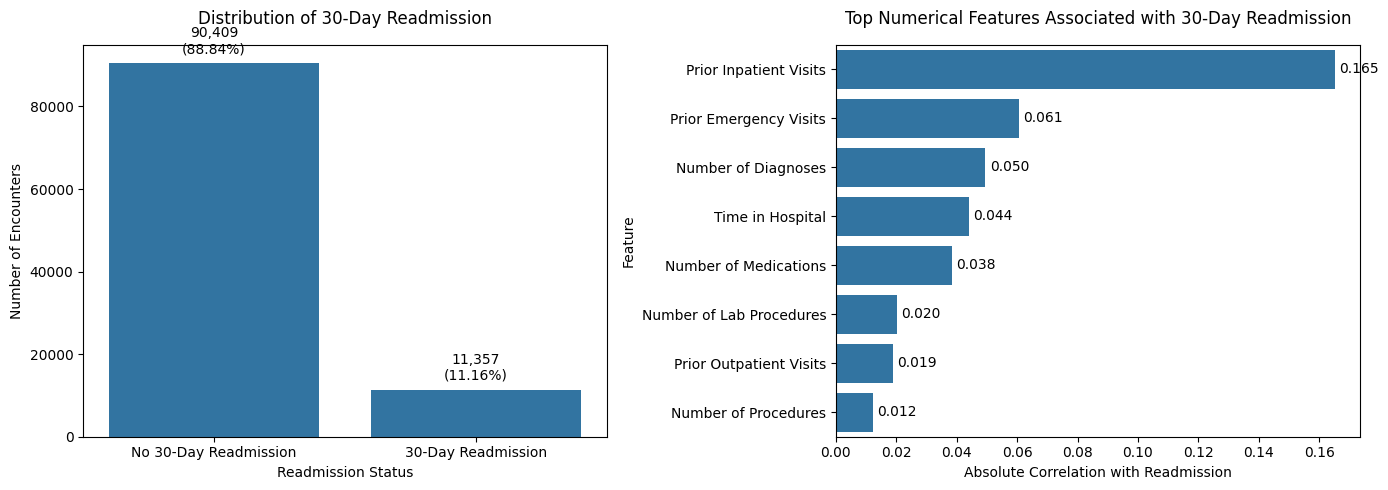

30-Day Readmission Summary by Race


,Race,Number of Encounters,Readmission Rate (%)
0,Caucasian,76099,11.29
1,AfricanAmerican,19210,11.22
2,Hispanic,2037,10.41
3,Asian,641,10.14
4,Other,1506,9.63


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# 1. Overall 30-Day Readmission Distribution
# ------------------------------------------------------------

ax1 = sns.countplot(
    data=df,
    x="readmitted_30",
    ax=axes[0]
)

axes[0].set_title(
    "Distribution of 30-Day Readmission",
    pad=15
)

axes[0].set_xlabel("Readmission Status")
axes[0].set_ylabel("Number of Encounters")

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(
    [
        "No 30-Day Readmission",
        "30-Day Readmission"
    ]
)

counts = (
    df["readmitted_30"]
    .value_counts()
    .sort_index()
)

percentages = (
    df["readmitted_30"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

for i, bar in enumerate(ax1.patches):
    count = counts.iloc[i]
    percent = percentages.iloc[i]

    ax1.annotate(
        f"{count:,}\n({percent:.2f}%)",
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points"
    )


# ------------------------------------------------------------
# 2. Numerical Feature Relevance
# ------------------------------------------------------------

numeric_cols = (
    df.select_dtypes(include=np.number)
    .columns
    .difference([
        "encounter_id",
        "patient_nbr",
        "readmitted_30",
        "admission_type_id",
        "discharge_disposition_id",
        "admission_source_id"
    ])
)

feature_relevance = (
    df[list(numeric_cols) + ["readmitted_30"]]
    .corr()["readmitted_30"]
    .drop("readmitted_30")
    .abs()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

feature_relevance.columns = [
    "Feature",
    "Absolute Correlation"
]

feature_relevance["Feature Label"] = (
    feature_relevance["Feature"]
    .map(feature_labels)
    .fillna(feature_relevance["Feature"])
)

ax2 = sns.barplot(
    data=feature_relevance,
    x="Absolute Correlation",
    y="Feature Label",
    ax=axes[1]
)

axes[1].set_title(
    "Top Numerical Features Associated with 30-Day Readmission",
    pad=15
)

axes[1].set_xlabel(
    "Absolute Correlation with Readmission"
)
axes[1].set_ylabel("Feature")

for container in ax2.containers:
    ax2.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Race-Level Readmission Summary
# ------------------------------------------------------------

race_readmission = (
    df.dropna(subset=["race"])
    .groupby("race", observed=False)["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

# Convert readmission rate to percentage
race_readmission["Readmission Rate (%)"] = (
    race_readmission["mean"] * 100
)

# Create readable race summary table
race_summary = (
    race_readmission[
        ["race", "count", "Readmission Rate (%)"]
    ]
    .rename(
        columns={
            "race": "Race",
            "count": "Number of Encounters"
        }
    )
    .sort_values(
        "Readmission Rate (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

print("30-Day Readmission Summary by Race")

display(
    race_summary.round({
        "Readmission Rate (%)": 2
    })
)

**Demographic Patterns in 30-Day Readmission**

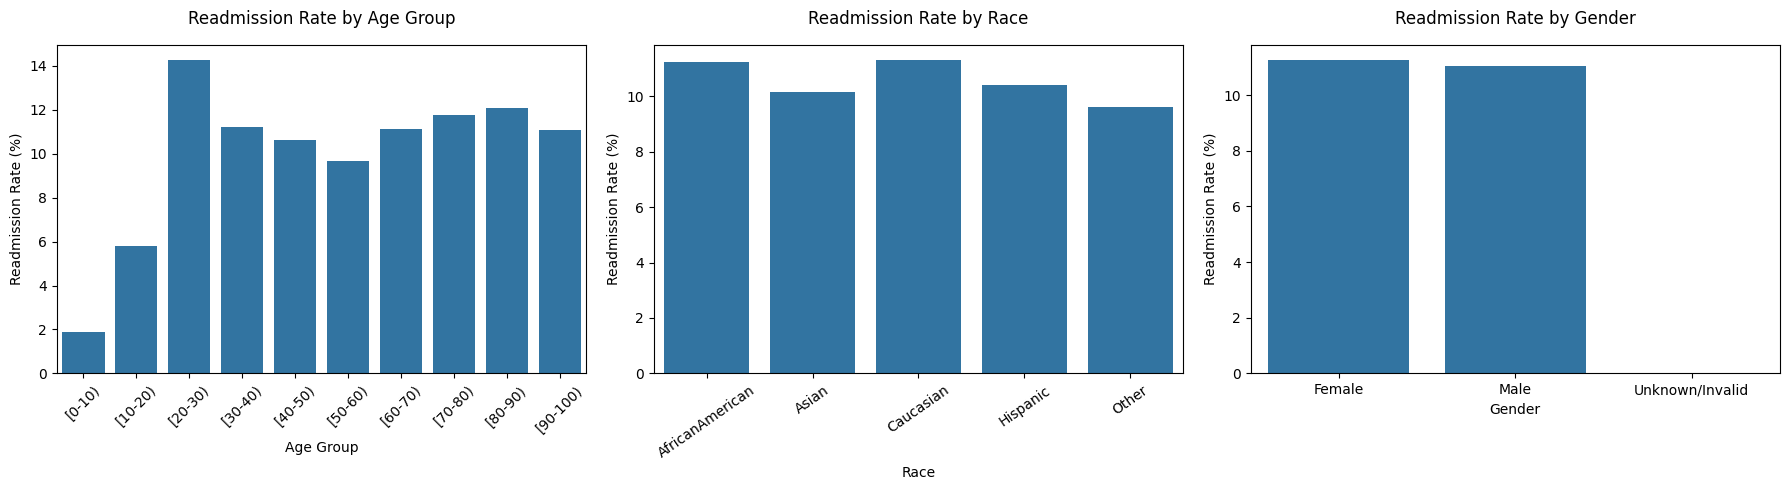

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ------------------------------------------------------------
# Age Group
# ------------------------------------------------------------

age_readmission = (
    df.groupby("age", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=age_readmission,
    x="age",
    y="Readmission Rate (%)",
    ax=axes[0]
)

axes[0].set_title(
    "Readmission Rate by Age Group",
    pad=15
)
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Readmission Rate (%)")
axes[0].tick_params(axis="x", rotation=45)


# ------------------------------------------------------------
# Race
# ------------------------------------------------------------

race_readmission = (
    df.dropna(subset=["race"])
    .groupby("race", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=race_readmission,
    x="race",
    y="Readmission Rate (%)",
    ax=axes[1]
)

axes[1].set_title(
    "Readmission Rate by Race",
    pad=15
)
axes[1].set_xlabel("Race")
axes[1].set_ylabel("Readmission Rate (%)")
axes[1].tick_params(axis="x", rotation=35)


# ------------------------------------------------------------
# Gender
# ------------------------------------------------------------

gender_readmission = (
    df.groupby("gender", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=gender_readmission,
    x="gender",
    y="Readmission Rate (%)",
    ax=axes[2]
)

axes[2].set_title(
    "Readmission Rate by Gender",
    pad=15
)
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

**Prior Healthcare Utilization and Readmission**

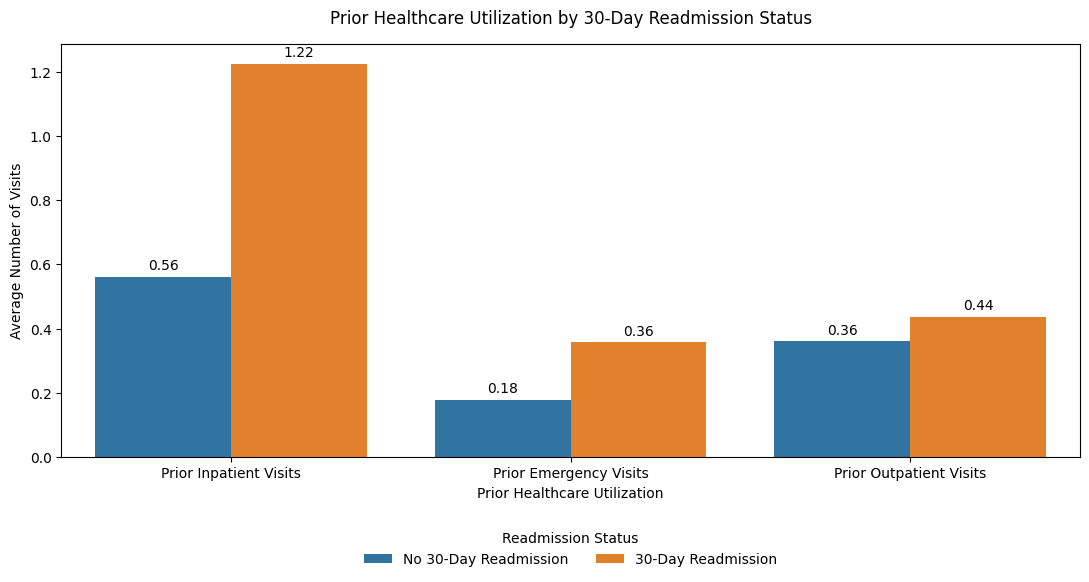

In [12]:
# Features representing healthcare utilization in the prior year
utilization_features = [
    "number_inpatient",
    "number_emergency",
    "number_outpatient"
]

# Calculate average prior visits for each readmission group
utilization_summary = []

for feature in utilization_features:

    no_readmission_mean = df.loc[
        df["readmitted_30"] == 0,
        feature
    ].mean()

    readmission_mean = df.loc[
        df["readmitted_30"] == 1,
        feature
    ].mean()

    utilization_summary.append({
        "Feature": feature_labels.get(feature, feature),
        "No 30-Day Readmission": no_readmission_mean,
        "30-Day Readmission": readmission_mean
    })

# Convert results to DataFrame
utilization_df = pd.DataFrame(utilization_summary)

# Reshape for grouped bar chart
utilization_long = utilization_df.melt(
    id_vars="Feature",
    var_name="Readmission Status",
    value_name="Average Prior Visits"
)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=utilization_long,
    x="Feature",
    y="Average Prior Visits",
    hue="Readmission Status"
)

plt.title(
    "Prior Healthcare Utilization by 30-Day Readmission Status",
    pad=15
)

plt.xlabel("Prior Healthcare Utilization")
plt.ylabel("Average Number of Visits")

# Add values above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

# Place legend below the plot
plt.legend(
    title="Readmission Status",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()

**Discharge Disposition and 30-Day Readmission**

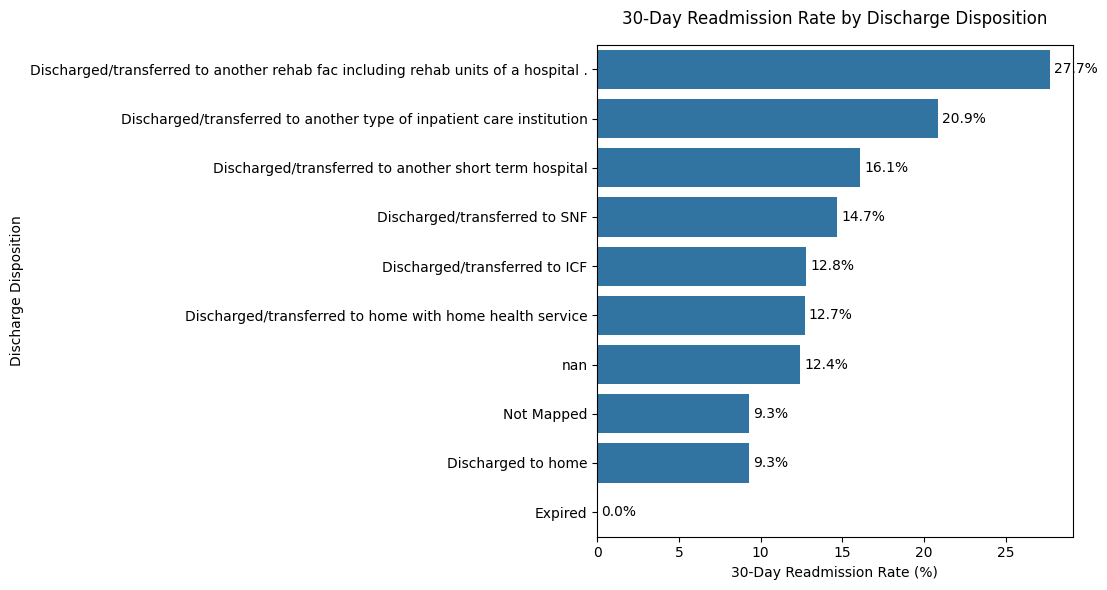

In [13]:
discharge_summary = (
    df.groupby(
        "discharge_disposition_label",
        observed=False
    )["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

discharge_summary[
    "Readmission Rate (%)"
] = (
    discharge_summary["mean"]
    * 100
)

discharge_summary = (
    discharge_summary
    .rename(
        columns={
            "discharge_disposition_label":
                "Discharge Disposition",

            "count":
                "Number of Encounters"
        }
    )
)

# Select the 10 most common discharge destinations
top_dispositions = (
    discharge_summary
    .nlargest(
        10,
        "Number of Encounters"
    )
    .sort_values(
        "Readmission Rate (%)",
        ascending=False
    )
)

plt.figure(
    figsize=(11, 6)
)

ax = sns.barplot(
    data=top_dispositions,
    x="Readmission Rate (%)",
    y="Discharge Disposition"
)

plt.title(
    "30-Day Readmission Rate by Discharge Disposition",
    pad=15
)

plt.xlabel(
    "30-Day Readmission Rate (%)"
)

plt.ylabel(
    "Discharge Disposition"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

**Clinical Care and Testing Patterns**

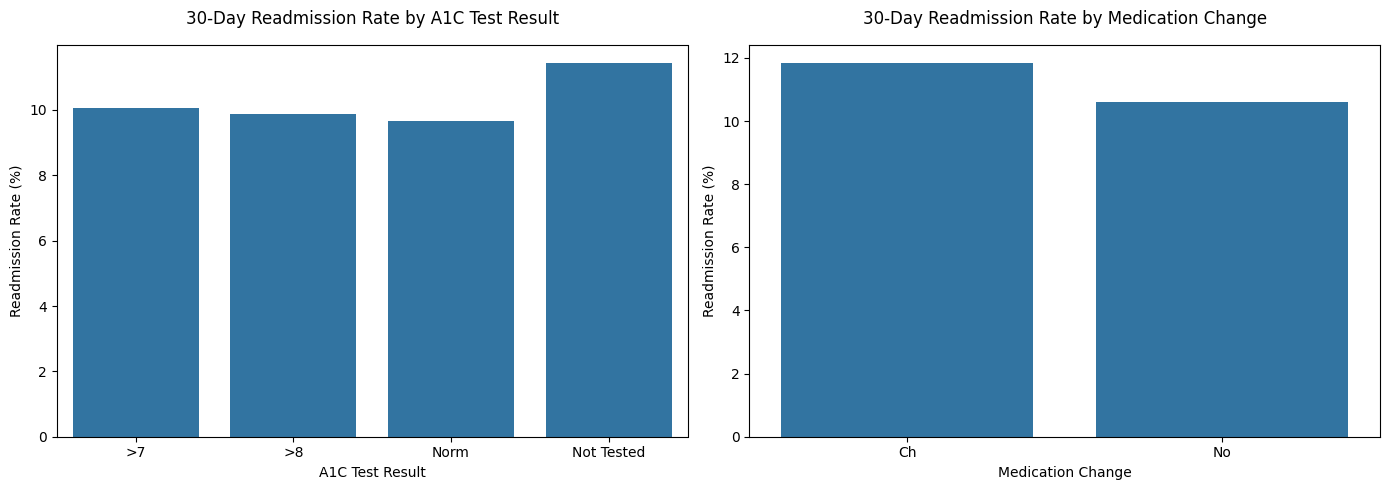

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------
# A1C Test Result
# ------------------------------------------------------------

a1c_readmission = (
    df.assign(
        A1C_Display=df["A1Cresult"].fillna("Not Tested")
    )
    .groupby("A1C_Display", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=a1c_readmission,
    x="A1C_Display",
    y="Readmission Rate (%)",
    ax=axes[0]
)

axes[0].set_title(
    "30-Day Readmission Rate by A1C Test Result",
    pad=15
)
axes[0].set_xlabel("A1C Test Result")
axes[0].set_ylabel("Readmission Rate (%)")


# ------------------------------------------------------------
# Medication Change
# ------------------------------------------------------------

change_readmission = (
    df.groupby("change", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index(name="Readmission Rate (%)")
)

sns.barplot(
    data=change_readmission,
    x="change",
    y="Readmission Rate (%)",
    ax=axes[1]
)

axes[1].set_title(
    "30-Day Readmission Rate by Medication Change",
    pad=15
)
axes[1].set_xlabel("Medication Change")
axes[1].set_ylabel("Readmission Rate (%)")

plt.tight_layout()
plt.show()

**Selected Numerical Feature Correlations**

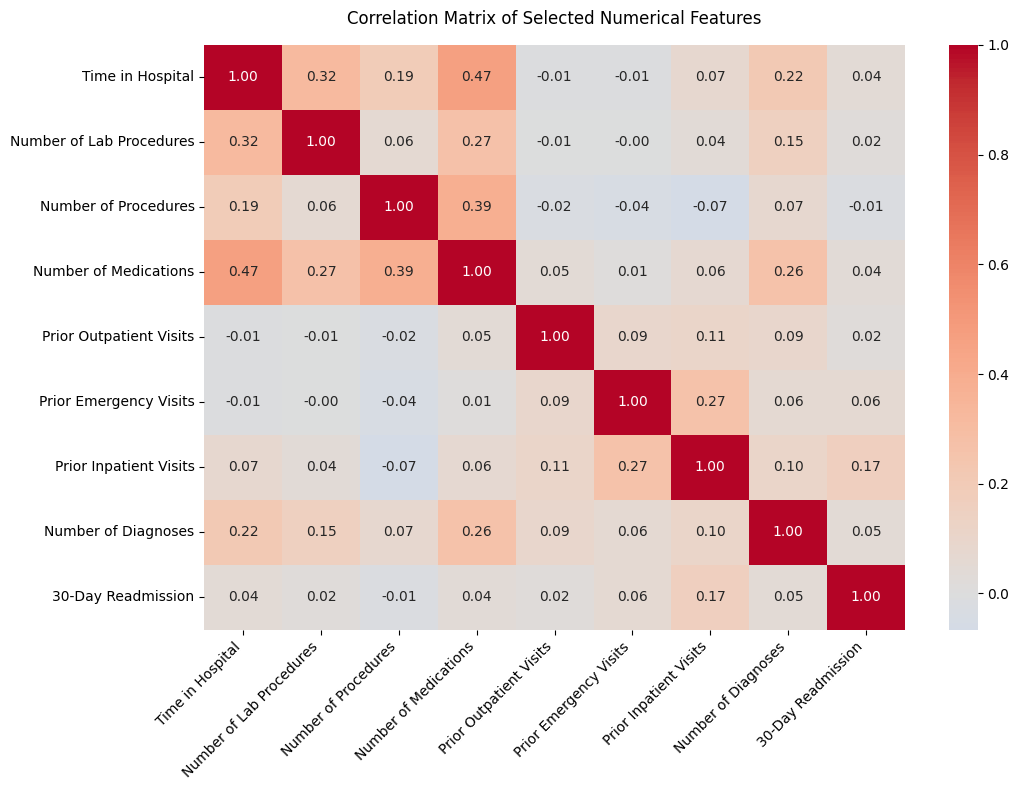

In [15]:
numeric_eda_features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "readmitted_30"
]

correlation_matrix = (
    df[numeric_eda_features]
    .corr()
)

readable_corr_labels = [
    feature_labels.get(feature, feature)
    for feature in correlation_matrix.columns
]

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    xticklabels=readable_corr_labels,
    yticklabels=readable_corr_labels
)

plt.title(
    "Correlation Matrix of Selected Numerical Features",
    pad=15
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Patient Encounter Assessment**

In [16]:
total_encounters = len(df)
unique_patients = df["patient_nbr"].nunique()
repeat_encounters = total_encounters - unique_patients

print(f"Total Encounters:  {total_encounters:,}")
print(f"Unique Patients:   {unique_patients:,}")
print(f"Repeat Encounters: {repeat_encounters:,}")

Total Encounters:  101,766
Unique Patients:   71,518
Repeat Encounters: 30,248


### **Feature Preparation**
This section prepares the dataset for machine learning by separating the predictors from the 30-day readmission target. Encounter ID and patient ID are excluded because they are identifiers, while the original readmission variable is removed to prevent target leakage. Administrative labels created for EDA are also excluded to avoid duplicate feature representations.

The data is divided into stratified training and testing sets to preserve the imbalanced target distribution. Numerical and categorical features are then identified, with administrative ID variables treated as categorical features. Missing numerical values are imputed using the median, missing categorical values using the most frequent category, and categorical predictors are transformed using one-hot encoding.

**Define Features and Target**

In [17]:
# ============================================================
# Define Features and Target
# ============================================================

# Administrative label columns are used only for readable EDA
# and are excluded from modeling to avoid duplicate representations.

X = df.drop(
    columns=[
        "encounter_id",
        "patient_nbr",
        "readmitted",
        "readmitted_30",
        "admission_type_label",
        "discharge_disposition_label",
        "admission_source_label"
    ]
)

y = df["readmitted_30"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (101766, 44)
Target Shape: (101766,)


**Train-Test Split**

In [18]:
# ============================================================
# Stratified Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

print("\nTraining Target Distribution:")
print(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

print("\nTesting Target Distribution:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .round(4)
)

Training Set: (81412, 44)
Testing Set: (20354, 44)

Training Target Distribution:
readmitted_30
0    0.8884
1    0.1116
Name: proportion, dtype: float64

Testing Target Distribution:
readmitted_30
0    0.8884
1    0.1116
Name: proportion, dtype: float64


**Identify Numerical and Categorical Features**

In [19]:
# These variables are stored numerically but represent categories
categorical_id_features = [
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id"
]

# True numerical features
numeric_features = (
    X.select_dtypes(include=np.number)
    .columns
    .difference(categorical_id_features)
    .tolist()
)

# Object/string categorical features
categorical_features = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

# Add categorical ID variables
categorical_features += categorical_id_features

print("Total Modeling Predictors:", X.shape[1])
print("Numerical Features:", len(numeric_features))
print("Categorical Features:", len(categorical_features))
print(
    "Total Identified:",
    len(numeric_features) + len(categorical_features)
)

Total Modeling Predictors: 44
Numerical Features: 8
Categorical Features: 36
Total Identified: 44


**Create Preprocessing Pipeline**

In [20]:
# Numerical preprocessing
numeric_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


### **Initial Model Development**
This section develops an initial Random Forest classifier to predict 30-day hospital readmission. Random Forest can capture complex, nonlinear relationships among numerical and categorical predictors while supporting feature-importance analysis.

The model uses 100 decision trees and a fixed random state for reproducibility. Preprocessing and classification are combined within a single pipeline to ensure consistent transformation of the training and testing data. The resulting performance provides the initial benchmark for evaluating the effect of model optimization.

**Build and Train Initial Random Forest Model**

In [21]:
random_forest_model = Pipeline(steps=[
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

random_forest_model.fit(
    X_train,
    y_train
)

print("Initial Random Forest model trained successfully.")

Initial Random Forest model trained successfully.


### **Model Evaluation**
This section evaluates the initial Random Forest using the training and held-out testing data. Training and testing accuracy are compared to assess generalization and potential overfitting.

Because the 30-day readmission target is highly imbalanced, performance is evaluated using accuracy, precision, recall, F1 score, and ROC-AUC. The classification report, confusion matrix, and ROC curve provide additional assessment of minority-class detection and overall discrimination. These results establish the initial performance benchmark for model optimization.

**Compare Training and Testing Accuracy**

In [22]:
train_accuracy = random_forest_model.score(
    X_train,
    y_train
)

test_accuracy = random_forest_model.score(
    X_test,
    y_test
)

accuracy_gap = (
    train_accuracy - test_accuracy
)

print("Training vs. Testing Accuracy")
print("-" * 35)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")
print(f"Accuracy Gap:      {accuracy_gap:.4f}")

Training vs. Testing Accuracy
-----------------------------------
Training Accuracy: 1.0000
Testing Accuracy:  0.8887
Accuracy Gap:      0.1113


**Evaluate Initial Model Performance**

In [23]:
# Generate predictions
y_pred = random_forest_model.predict(
    X_test
)

y_prob = random_forest_model.predict_proba(
    X_test
)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# Performance table
model_performance = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(
    model_performance.round(4)
)

,Metric,Score
0,Accuracy,0.8887
1,Precision,0.6875
2,Recall,0.0048
3,F1 Score,0.0096
4,ROC-AUC,0.6574


**Initial Classification Report**

In [24]:
print("Classification Report")
print("-" * 55)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No 30-Day Readmission",
            "30-Day Readmission"
        ],
        zero_division=0
    )
)

Classification Report
-------------------------------------------------------
                       precision    recall  f1-score   support

No 30-Day Readmission       0.89      1.00      0.94     18083
   30-Day Readmission       0.69      0.00      0.01      2271

             accuracy                           0.89     20354
            macro avg       0.79      0.50      0.48     20354
         weighted avg       0.87      0.89      0.84     20354



**Initial Confusion Matrix and ROC Curve**

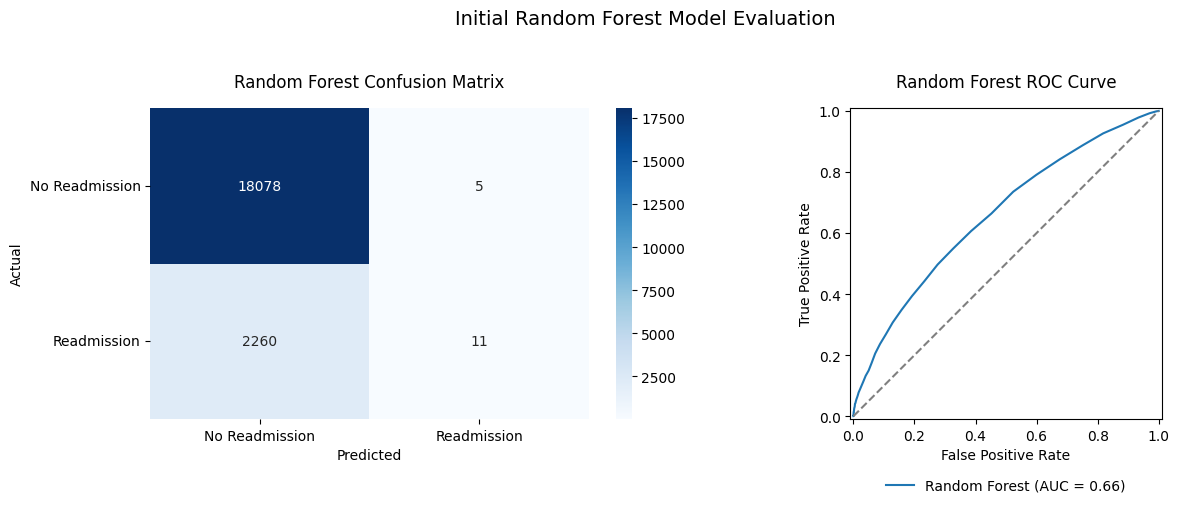

In [25]:
# Create confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    ax=axes[0]
)

axes[0].set_title(
    "Random Forest Confusion Matrix",
    pad=15
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[0].set_xticklabels(
    ["No Readmission", "Readmission"]
)

axes[0].set_yticklabels(
    ["No Readmission", "Readmission"],
    rotation=0
)

# ------------------------------------------------------------
# ROC Curve
# ------------------------------------------------------------

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    name="Random Forest",
    ax=axes[1]
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

axes[1].set_title(
    "Random Forest ROC Curve",
    pad=15
)

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")

axes[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    frameon=False
)

fig.suptitle(
    "Initial Random Forest Model Evaluation",
    fontsize=14,
    y=1.03
)

plt.tight_layout()
plt.show()

### **Initial Feature Importance and Model Summary**
This section examines the predictors contributing most strongly to the fitted Random Forest model and summarizes its initial predictive performance. Feature importance reflects each predictor's contribution to the model's predictions and should not be interpreted as evidence of a causal relationship.

**Initial Feature Importance**

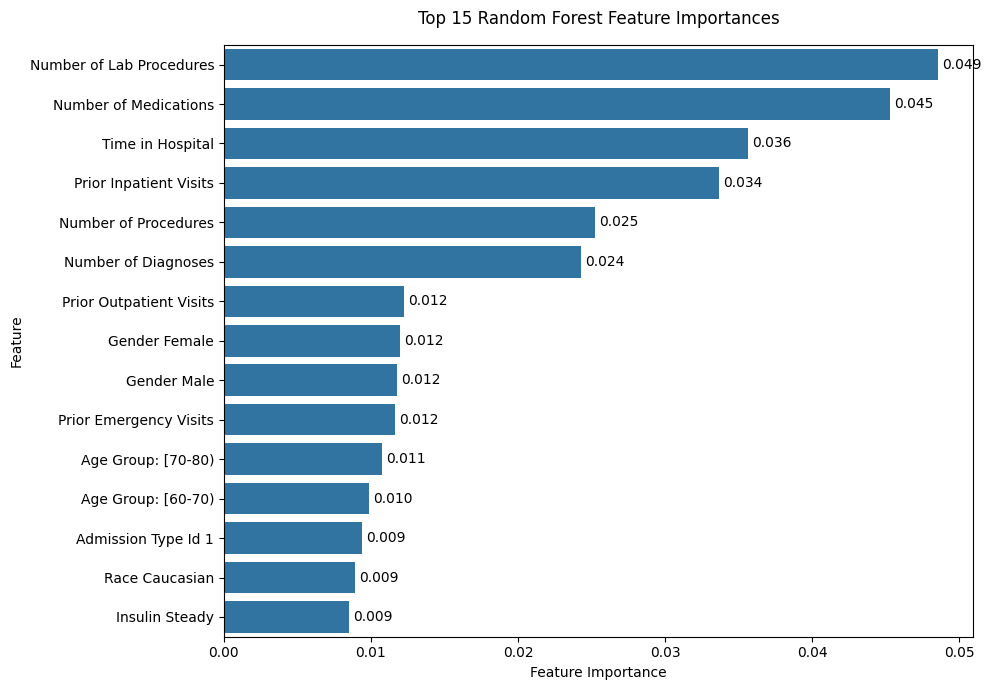

In [26]:
# Extract transformed feature names
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract fitted classifier
rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

# Create feature-importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_classifier.feature_importances_
})

# ------------------------------------------------------------
# Convert model feature names to readable labels
# ------------------------------------------------------------

def make_readable_feature_name(feature_name):

    feature_name = (
        feature_name
        .replace("numeric__", "")
        .replace("categorical__", "")
    )

    # Direct feature match
    if feature_name in feature_labels:
        return feature_labels[feature_name]

    # One-hot encoded categorical feature
    for original_name, readable_name in feature_labels.items():

        prefix = original_name + "_"

        if feature_name.startswith(prefix):

            category = feature_name[len(prefix):]

            return f"{readable_name}: {category}"

    # Fallback
    return (
        feature_name
        .replace("_", " ")
        .title()
    )


feature_importance["Feature Label"] = (
    feature_importance["Feature"]
    .apply(make_readable_feature_name)
)

# Select Top 15
top_features = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

# Plot
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature Label"
)

plt.title(
    "Top 15 Random Forest Feature Importances",
    pad=15
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=3
    )

plt.tight_layout()
plt.show()

**Initial Model Summary**

In [27]:
initial_model_summary = pd.DataFrame({
    "Model": [
        "Random Forest"
    ],
    "Training Accuracy": [
        train_accuracy
    ],
    "Testing Accuracy": [
        test_accuracy
    ],
    "Accuracy Gap": [
        accuracy_gap
    ],
    "Precision": [
        precision
    ],
    "Recall": [
        recall
    ],
    "F1 Score": [
        f1
    ],
    "ROC-AUC": [
        roc_auc
    ]
})

print(
    "Initial Random Forest Performance Summary"
)

display(
    initial_model_summary.round(4)
)

Initial Random Forest Performance Summary


,Model,Training Accuracy,Testing Accuracy,Accuracy Gap,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,1.0,0.8887,0.1113,0.6875,0.0048,0.0096,0.6574


### **Optimization and Evaluation**
This section optimizes the Random Forest to improve generalization and detection of the minority 30-day readmission class. RandomizedSearchCV with five-fold stratified cross-validation is applied to the training data, while the held-out test set remains separate for final evaluation.

F1 score is used as the optimization criterion to balance precision and recall under substantial class imbalance. The search evaluates the number of trees, maximum depth, minimum samples per leaf, and class weighting. The tuned model is then compared with the initial Random Forest using the same evaluation metrics.

**Random Forest Hyperparameter Optimization**

In [28]:
# ============================================================
# 5-Fold Stratified Cross-Validation
# and Random Forest Hyperparameter Optimization
# ============================================================

# Define 5-fold stratified cross-validation
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Create a separate Random Forest pipeline for tuning
# RandomizedSearchCV handles parallel processing
rf_tuning_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

# Focused hyperparameter search space
param_distributions = {
    "classifier__n_estimators": [
        100,
        150
    ],
    "classifier__max_depth": [
        8,
        12,
        16
    ],
    "classifier__min_samples_leaf": [
        2,
        5,
        10
    ],
    "classifier__class_weight": [
        "balanced",
        "balanced_subsample"
    ]
}

# Configure randomized search
rf_search = RandomizedSearchCV(
    estimator=rf_tuning_model,
    param_distributions=param_distributions,
    n_iter=6,
    scoring="f1",
    cv=stratified_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Run optimization using training data only
rf_search.fit(
    X_train,
    y_train
)

# Display optimization results
print("\nRandom Forest optimization completed.")

print("\nBest Parameters:")
for parameter, value in rf_search.best_params_.items():
    print(f"{parameter}: {value}")

print(
    f"\nBest Cross-Validated F1 Score: "
    f"{rf_search.best_score_:.4f}"
)

Fitting 5 folds for each of 6 candidates, totalling 30 fits

Random Forest optimization completed.

Best Parameters:
classifier__n_estimators: 150
classifier__min_samples_leaf: 2
classifier__max_depth: 16
classifier__class_weight: balanced

Best Cross-Validated F1 Score: 0.2728


**Evaluate Tuned Random Forest**

In [29]:
tuned_rf_model = (
    rf_search.best_estimator_
)

# Training/testing accuracy
tuned_train_accuracy = (
    tuned_rf_model.score(
        X_train,
        y_train
    )
)

tuned_test_accuracy = (
    tuned_rf_model.score(
        X_test,
        y_test
    )
)

tuned_accuracy_gap = (
    tuned_train_accuracy
    - tuned_test_accuracy
)

# Predictions
tuned_pred = tuned_rf_model.predict(
    X_test
)

tuned_prob = tuned_rf_model.predict_proba(
    X_test
)[:, 1]

# Metrics
tuned_accuracy = accuracy_score(
    y_test,
    tuned_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_pred,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    tuned_pred,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    tuned_pred,
    zero_division=0
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_prob
)

print("Tuned Random Forest Performance")
print("-" * 40)

print(
    f"Training Accuracy: "
    f"{tuned_train_accuracy:.4f}"
)

print(
    f"Testing Accuracy:  "
    f"{tuned_test_accuracy:.4f}"
)

print(
    f"Accuracy Gap:      "
    f"{tuned_accuracy_gap:.4f}"
)

print(
    f"Precision:         "
    f"{tuned_precision:.4f}"
)

print(
    f"Recall:            "
    f"{tuned_recall:.4f}"
)

print(
    f"F1 Score:          "
    f"{tuned_f1:.4f}"
)

print(
    f"ROC-AUC:           "
    f"{tuned_roc_auc:.4f}"
)

Tuned Random Forest Performance
----------------------------------------
Training Accuracy: 0.6904
Testing Accuracy:  0.6708
Accuracy Gap:      0.0196
Precision:         0.1858
Recall:            0.5764
F1 Score:          0.2810
ROC-AUC:           0.6810


**Initial vs. Tuned Model Comparison**

In [30]:
model_comparison = pd.DataFrame({

    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Accuracy Gap",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],

    "Initial Random Forest": [
        train_accuracy,
        test_accuracy,
        accuracy_gap,
        precision,
        recall,
        f1,
        roc_auc
    ],

    "Tuned Random Forest": [
        tuned_train_accuracy,
        tuned_test_accuracy,
        tuned_accuracy_gap,
        tuned_precision,
        tuned_recall,
        tuned_f1,
        tuned_roc_auc
    ]
})

model_comparison["Change"] = (
    model_comparison[
        "Tuned Random Forest"
    ]
    - model_comparison[
        "Initial Random Forest"
    ]
)

display(
    model_comparison.round(4)
)

,Metric,Initial Random Forest,Tuned Random Forest,Change
0,Training Accuracy,1.0000,0.6904,-0.3096
1,Testing Accuracy,0.8887,0.6708,-0.2179
2,Accuracy Gap,0.1113,0.0196,-0.0917
3,Precision,0.6875,0.1858,-0.5017
4,Recall,0.0048,0.5764,0.5716
5,F1 Score,0.0096,0.2810,0.2713
6,ROC-AUC,0.6574,0.6810,0.0237


**Performance Improvement Visualization**

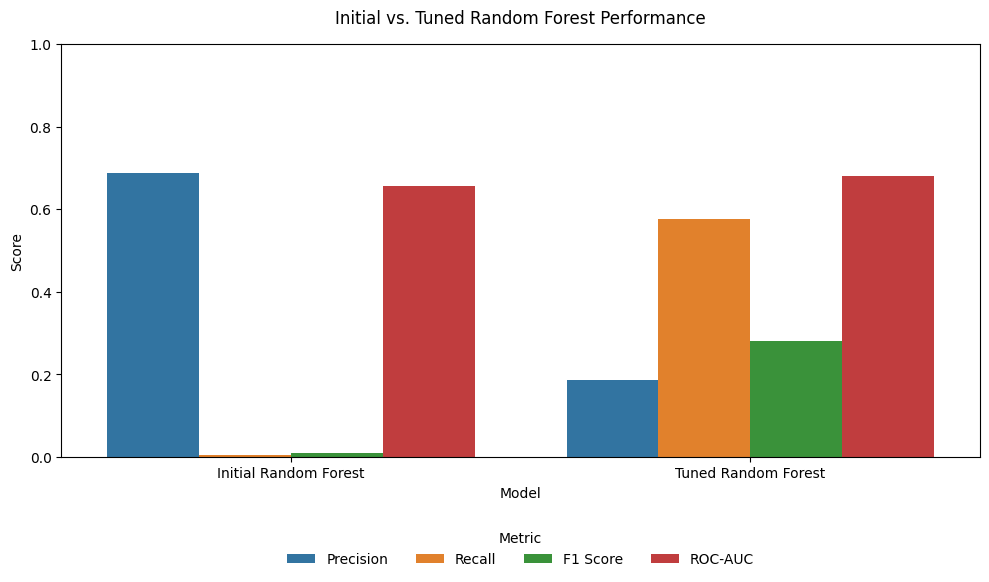

In [31]:
comparison_plot = pd.DataFrame({

    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest"
    ],

    "Precision": [
        precision,
        tuned_precision
    ],

    "Recall": [
        recall,
        tuned_recall
    ],

    "F1 Score": [
        f1,
        tuned_f1
    ],

    "ROC-AUC": [
        roc_auc,
        tuned_roc_auc
    ]
})

comparison_long = (
    comparison_plot.melt(
        id_vars="Model",
        var_name="Metric",
        value_name="Score"
    )
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=comparison_long,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Initial vs. Tuned Random Forest Performance",
    pad=15
)

plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(
    title="Metric",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False
)

plt.tight_layout()
plt.show()

**Tuned Classification Report**

In [32]:
# ============================================================
# Tuned Random Forest Classification Report
# ============================================================

print("Tuned Random Forest Classification Report")
print("-" * 55)

print(
    classification_report(
        y_test,
        tuned_pred,
        target_names=[
            "No 30-Day Readmission",
            "30-Day Readmission"
        ],
        zero_division=0
    )
)

Tuned Random Forest Classification Report
-------------------------------------------------------
                       precision    recall  f1-score   support

No 30-Day Readmission       0.93      0.68      0.79     18083
   30-Day Readmission       0.19      0.58      0.28      2271

             accuracy                           0.67     20354
            macro avg       0.56      0.63      0.53     20354
         weighted avg       0.84      0.67      0.73     20354



**Tuned Confusion Matrix and ROC Curve**

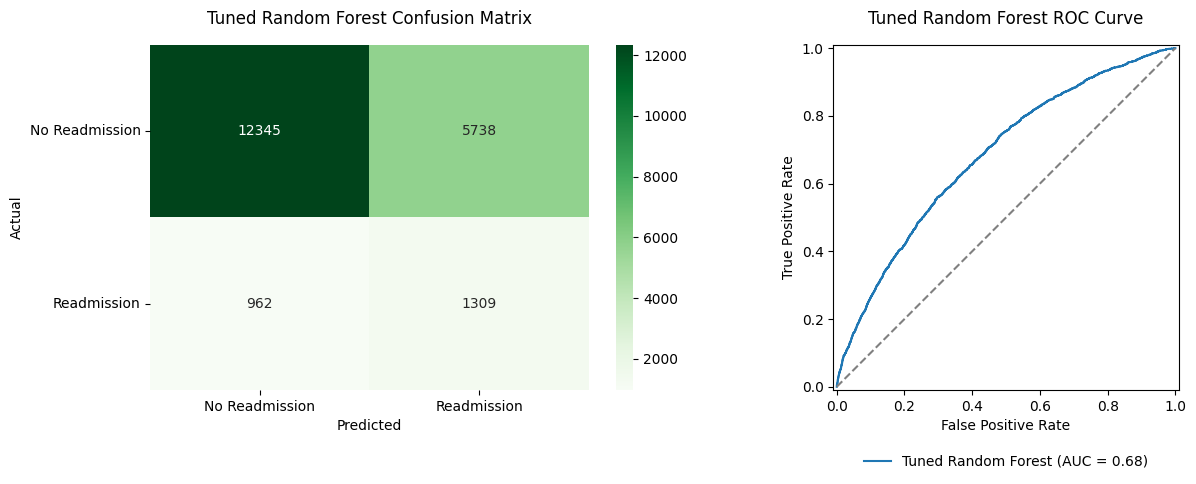

In [33]:
# ============================================================
# Tuned Random Forest Evaluation
# ============================================================

tuned_cm = confusion_matrix(
    y_test,
    tuned_pred
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5)
)

# Confusion Matrix
sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=True,
    ax=axes[0]
)

axes[0].set_title(
    "Tuned Random Forest Confusion Matrix",
    pad=15
)

axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

axes[0].set_xticklabels([
    "No Readmission",
    "Readmission"
])

axes[0].set_yticklabels(
    [
        "No Readmission",
        "Readmission"
    ],
    rotation=0
)

# ROC Curve
RocCurveDisplay.from_predictions(
    y_test,
    tuned_prob,
    name="Tuned Random Forest",
    ax=axes[1]
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray"
)

axes[1].set_title(
    "Tuned Random Forest ROC Curve",
    pad=15
)

axes[1].set_xlabel(
    "False Positive Rate"
)

axes[1].set_ylabel(
    "True Positive Rate"
)

axes[1].legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    frameon=False
)

plt.tight_layout()
plt.show()

**Final Optimization Summary**

In [34]:
print("Random Forest Optimization Summary")
print("-" * 45)

print(
    f"Recall: "
    f"{recall:.4f} -> {tuned_recall:.4f}"
)

print(
    f"F1 Score: "
    f"{f1:.4f} -> {tuned_f1:.4f}"
)

print(
    f"ROC-AUC: "
    f"{roc_auc:.4f} -> {tuned_roc_auc:.4f}"
)

print(
    f"Accuracy Gap: "
    f"{accuracy_gap:.4f} -> "
    f"{tuned_accuracy_gap:.4f}"
)

print(
    "\nBest Cross-Validated F1 Score: "
    f"{rf_search.best_score_:.4f}"
)

Random Forest Optimization Summary
---------------------------------------------
Recall: 0.0048 -> 0.5764
F1 Score: 0.0096 -> 0.2810
ROC-AUC: 0.6574 -> 0.6810
Accuracy Gap: 0.1113 -> 0.0196

Best Cross-Validated F1 Score: 0.2728
